--- Map saved successfully: True Colour_NDVI_Map_2025.png ---


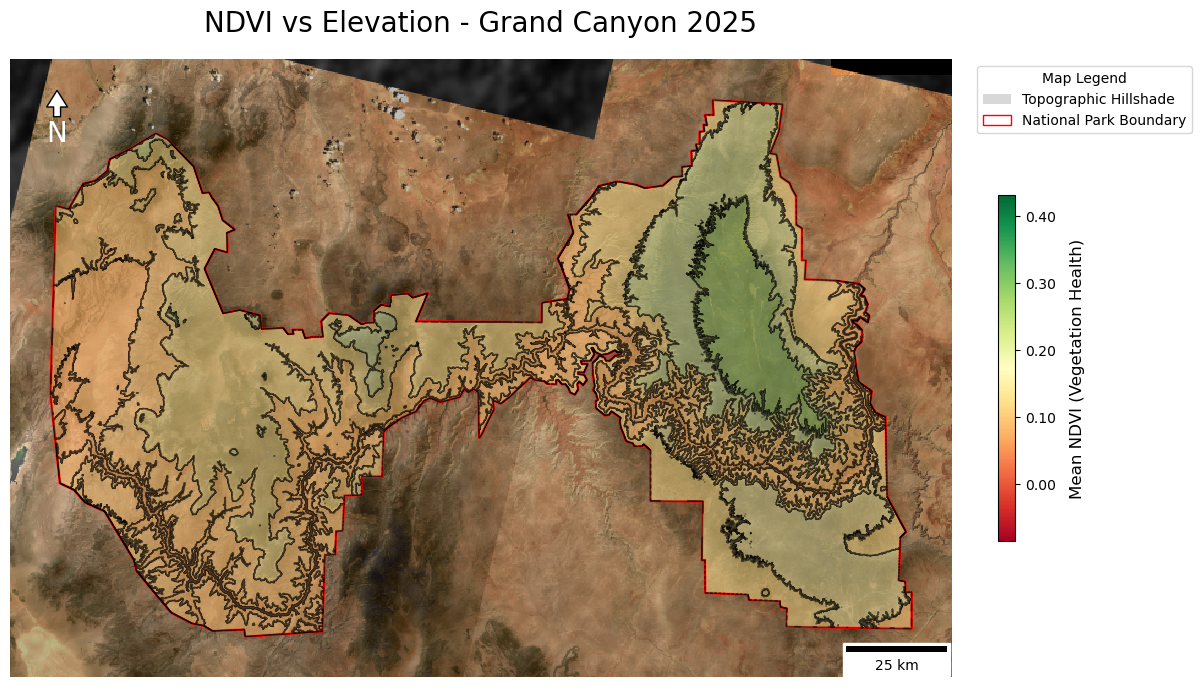

--- Plot saved successfully: NDVI_vs_elevation_2025.png ---


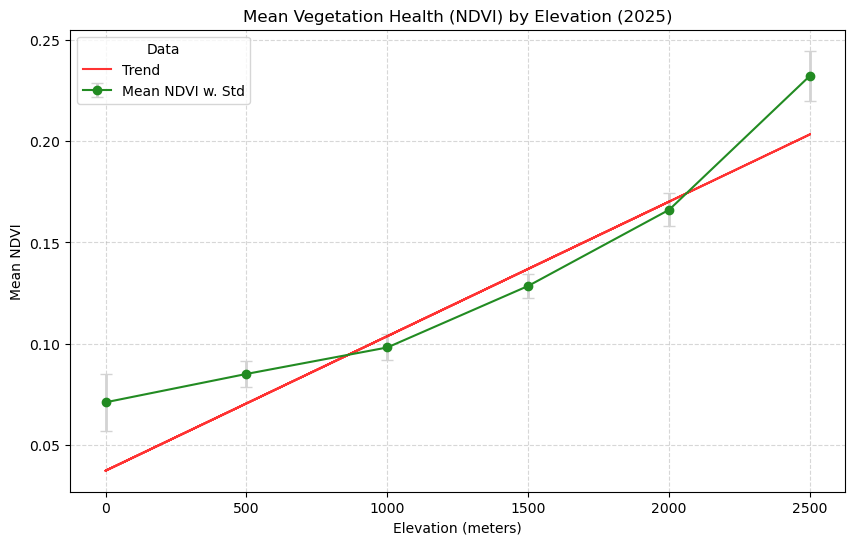

In [1]:
"""
Project Title: Elevation-based NDVI Analysis
Author: James McLoughlin
Date: May 2026
Description: This script processes DEM and Landsat data to calculate zonal statistics for vegetation health across different elevation zones.
"""

# =============================================================================
# Library Imports
# =============================================================================
from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
from xrspatial import hillshade
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter




# =============================================================================
# MAP CONFIGURATION & PARAMETER SETTINGS
# =============================================================================

# --- 1. User Configuration ---
# =============================================================================
# Change variables to control the visual output of the final map
image_choice = "True Colour" # Options: "True Colour", "False Colour"
data_display = "NDVI"        # Options: "Elevation", "NDVI"

# Define the root directory of data
base = Path("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Data")

# --- 2. Folder structure and option mapping ---
# =============================================================================
# paths to the folders where data is stored
PATHS = {
    "mosaics": base / "Mosaics",
    "vectors": base / "Vector_Layers",
    "results": base / "Results"
}

# Defines which satellite image file to use based on the user's choice above
image_files = {
    "True Colour": "2025_true_colour_composite.tif",
    "False Colour": "2025_false_colour_composite.tif" # Ensure this file exists
}

# Defines the visual styles (colors and titles) for the different data layers
data_config = {
    "Elevation": {"col": "elevation_zone", "cmap": "terrain", "title": "Elevation Zones"},
    "NDVI": {"col": "mean", "cmap": "RdYlGn", "title": "Mean NDVI"} 
}

# Apply the selections made by the user in Section 1
img_filename = image_files[image_choice]
active_config = data_config[data_display]


# --- 2. Preparing Landsat Image and ROI ---
# =============================================================================
# Open the selected composite image and find its coordinate system (CRS)
img_path = PATHS['results'] / img_filename
with rioxarray.open_rasterio(img_path) as src:
    img_crs = src.rio.crs
    
# Load the National Park boundary (ROI) and reproject to match the CRS of the composite image
roi_raw = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
roi = roi_raw.to_crs(img_crs)
minx, miny, maxx, maxy = roi.total_bounds

# Create a 'bounding box' around the park using buffer to include reagion outsite of ROI
buffer = 10000
bbox = [minx - buffer, miny - buffer, maxx + buffer, maxy + buffer]

# Open the composite image and immediately 'clip' to the 'bounding box'. Reduces memory usage
img = rioxarray.open_rasterio(img_path, mask_and_scale=True).rio.clip_box(*bbox)

# Adjust the image brightness (gamma) and contrast (rescaling) to improve the imge quality
gamma = 0.8
vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
img_scaled = ((img - vmin)/(vmax-vmin)*255).fillna(0).clip(0, 255)
img_scaled = (255 * (img_scaled / 255) ** gamma).fillna(0).astype("uint8")

# Shrink the image resolution (downsample) to make the final plotting faster
img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().astype("uint8")


# --- 3. Preparing Hillshade ---
# =============================================================================
# This section laods the DEM file and creates a hillsahde
# DEM file path
dem_path = PATHS["mosaics"] / "DEM_mosaic.TIF"

# Load DEM and generate hillshade
elevation_da = rioxarray.open_rasterio(dem_path, masked=True).squeeze()
hs_raw = hillshade(elevation_da, azimuth=225, angle_altitude=45)

# Reproject to match low-res image CRS
hs_matched = hs_raw.rio.reproject_match(img_low_res)

# Apply Gaussian blur to remove high frequency noise (i.e. smooth) the hillshade
hs_smooth_array = gaussian_filter(hs_matched, sigma=3)

# Return smoothed hillshade to Xarray DataArray to maintin coordinates
#hs_smooth = hs.squeeze().copy(data=hs_smooth_array)
hs_smooth = hs_matched.copy(data=hs_smooth_array)

out_filename = PATHS["results"] / "hillshade_smoothed.tif"
hs_smooth.rio.to_raster(out_filename)


# --- 4. Loading Spatial Data ---
# =============================================================================
# Load the elevation and NDVI zonal statistics 
# clip dataset to ROI to remove bounding box that otherwise appears in map
spatial_data = gpd.read_file(PATHS["results"] /"elevation_zones_with_stats_2025.gpkg")
spatial_data_clipped = gpd.clip(spatial_data, roi)


# --- 5. Creating Figure ---
# =============================================================================
fig, ax = plt.subplots(figsize=(15, 15))

# Draw composite image as base layer and add hillshade
img_low_res.plot.imshow(ax=ax)
hs_smooth.plot.imshow(ax=ax, cmap='gray', alpha=0.4, add_colorbar=False)

# Overlay outline of ROI (National Park boundary)
roi.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# Overlay the data (NDVI or Elevation)
spatial_data_clipped.plot(ax=ax, column=active_config['col'], cmap=active_config['cmap'], alpha=0.5, edgecolor='black')


# --- 6. Legend Construction ---
# =============================================================================
# This section builds the legend based on the sleced display optons
# setup list of legend elements
legend_elements = []

cmap = plt.get_cmap(active_config['cmap'])

# Legend construction for the  'Elevation' data - boxes for each elevation step.
if data_display == "Elevation":
    # Extract the unique elevation values in the data
    unique_vals = sorted(spatial_data_clipped[active_config['col']].unique())

    # If more than one elevation exisits calualte the step size, and normalise the elevation range
    step = unique_vals[1] - unique_vals[0] if len(unique_vals) > 1 else 0
    norm = plt.Normalize(vmin=min(unique_vals), vmax=max(unique_vals))
    
    # Add box for each elevation zone to the legend
    legend_elements.append(mpatches.Patch(color='none', label='--- Elevation Zones ---'))
    for val in unique_vals:
        color = cmap(norm(val))
        label_text = f"{int(val)} - {int(val + step)} m" 
        legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.4, label=label_text))

    # Add an empty space to legend to separate evelaction elements from the boundary elemments
    legend_elements.append(mpatches.Patch(color='none', label='')) # Spacer
    
# Legend construction for the 'NDVI' data -  Continuous NDVI Colorbar
elif data_display == "NDVI":
    # Find the max and mim on the mean NDVI data and normalise the range
    data_min = spatial_data_clipped[active_config['col']].min()
    data_max = spatial_data_clipped[active_config['col']].max()
    norm = plt.Normalize(vmin=data_min, vmax=data_max)
    
    # Create custom colourbar linked to data range and colour scheme.
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []  # Required hack for matplotlib to recognize the colourbar 
    
    # Describe the format , size, location of the colourbar
    cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.04, format='%.2f')  #format='%.2f' limited siaplyed numbers to 2dp
    cbar.set_label('Mean NDVI (Vegetation Health)', fontsize=12, labelpad=10)

# Add constant items (Hillshade and ROI) to legend
legend_elements.append(mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade'))
legend_elements.append(mpatches.Patch(edgecolor='red', facecolor='none', label='National Park Boundary'))


# # Place the final legend box outside the map to avoid covering data.
ax.legend(handles=legend_elements, loc='upper left', title="Map Legend", 
          bbox_to_anchor=(1.02, 1), fontsize=10, frameon=True)


# --- 7. Map Elements ---
# =============================================================================
# Add a scale bar to help the reader judge distances on the map.
ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))

# Add a North Arrow to map 
x, y, arrow_length = 0.05, 0.95, 0.07
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.88),
            arrowprops=dict(facecolor='white', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, color='white', xycoords='axes fraction')

# Set plot title 
ax.set_title("NDVI vs Elevation - Grand Canyon 2025", fontsize=20, pad=20)
ax.set_axis_off()


# --- 8. Save the Plot ---
# =============================================================================
# Generate a filename and destination based on the user's settings
output_map_name = f"{image_choice}_{data_display}_Map_2025.png"
save_path = PATHS["results"] / output_map_name

# Save as a high-res (300 DPI) image
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"--- Map saved successfully: {output_map_name} ---")

plt.show()



# =============================================================================
# Graph Plotting
# =============================================================================


# --- 1. Preapring Spatial data ---
# =============================================================================
# Clean the data: Remove "NoData" or "NaNs" that would cause calualtion errors
plot_data = spatial_data.dropna(subset=['mean'])

# Group the data by elevation zone, calculate the mean NDVI and std for each elevation band
elevation_profile = spatial_data.groupby('elevation_zone').agg({
    'mean': 'mean', 
    'std': 'mean'
}).reset_index().dropna()


# --- 2. Creating Plot ---
# =============================================================================
# Initialise figure
plt.figure(figsize=(10, 6))

# Plot the mean NDVI and std (errorbars) per elevation zone
plt.errorbar(
    elevation_profile['elevation_zone'], 
    elevation_profile['mean'], 
    yerr=elevation_profile['std'], 
    fmt='o-',           # 'o' for points, '-' for connecting line
    color='forestgreen', 
    ecolor='lightgray',
    elinewidth=2, 
    capsize=4, 
    label='Mean NDVI w. Std'
)

# Calculate trend line and add to plot
z = np.polyfit(plot_data['elevation_zone'], plot_data['mean'], 1)
p = np.poly1d(z)
plt.plot(plot_data['elevation_zone'], p(plot_data['elevation_zone']), "r", alpha=0.8, label="Trend")

# Formatting the chart with title and axis labels
plt.title("Mean Vegetation Health (NDVI) by Elevation (2025)")
plt.xlabel("Elevation (meters)")
plt.ylabel("Mean NDVI")
plt.legend(title="Data")
plt.grid(True, linestyle='--', alpha=0.5)


# --- 3. Saving Plot ---
# =============================================================================
# Generate a filename and destination forth file
output_map_name = f"NDVI_vs_elevation_2025.png"
save_path = PATHS["results"] / output_map_name

# Save as a high-res (300 DPI) image
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"--- Plot saved successfully: {output_map_name} ---")
plt.show()